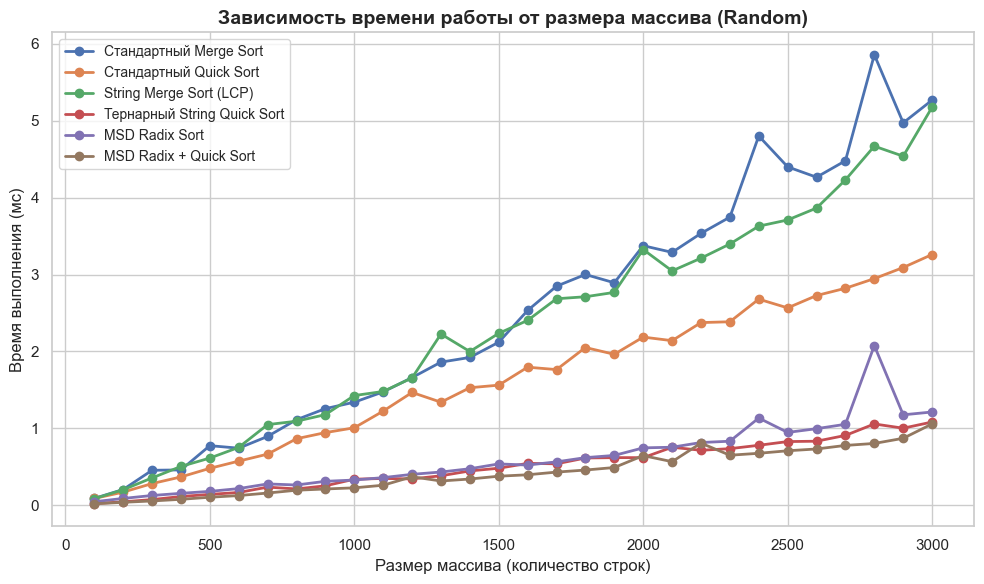

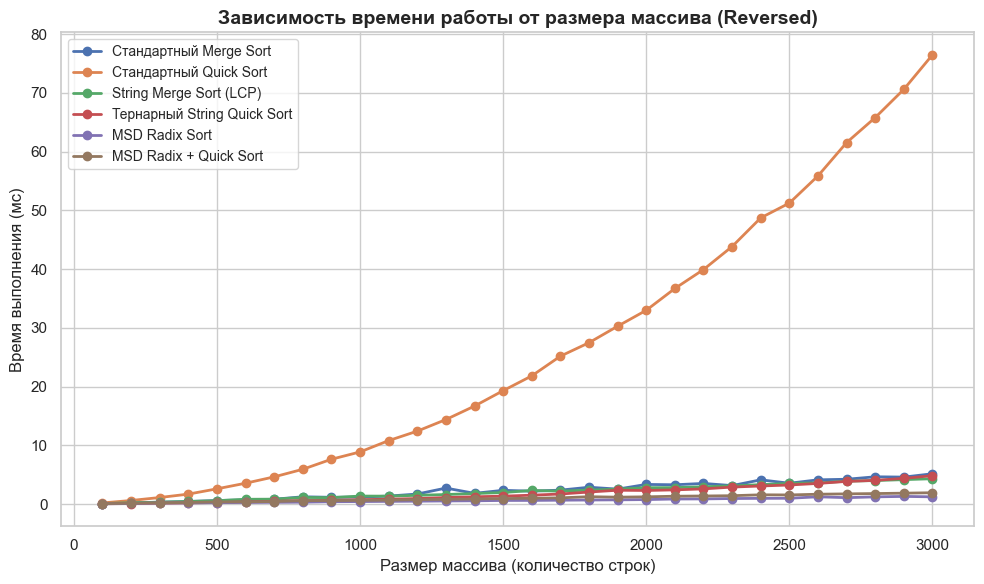

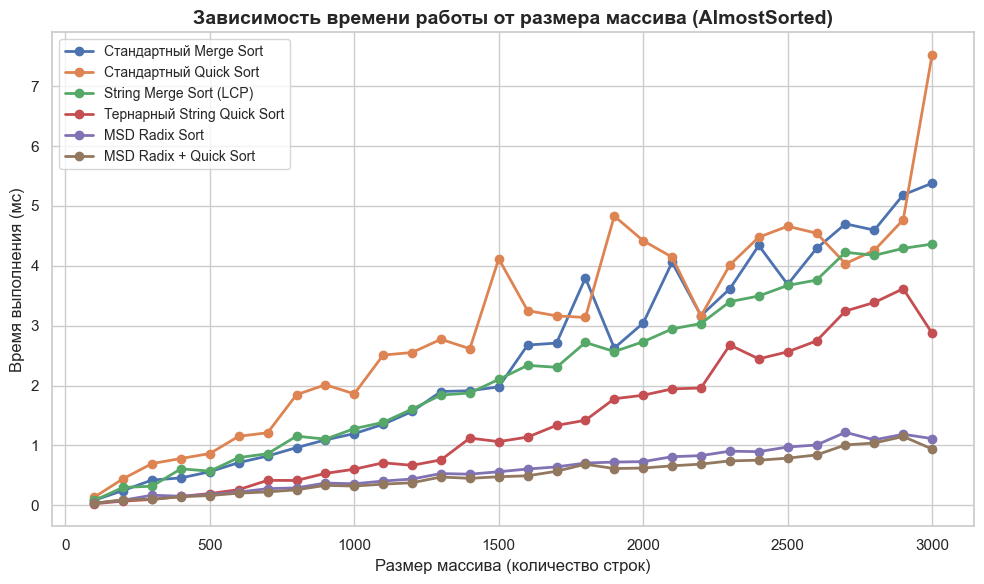

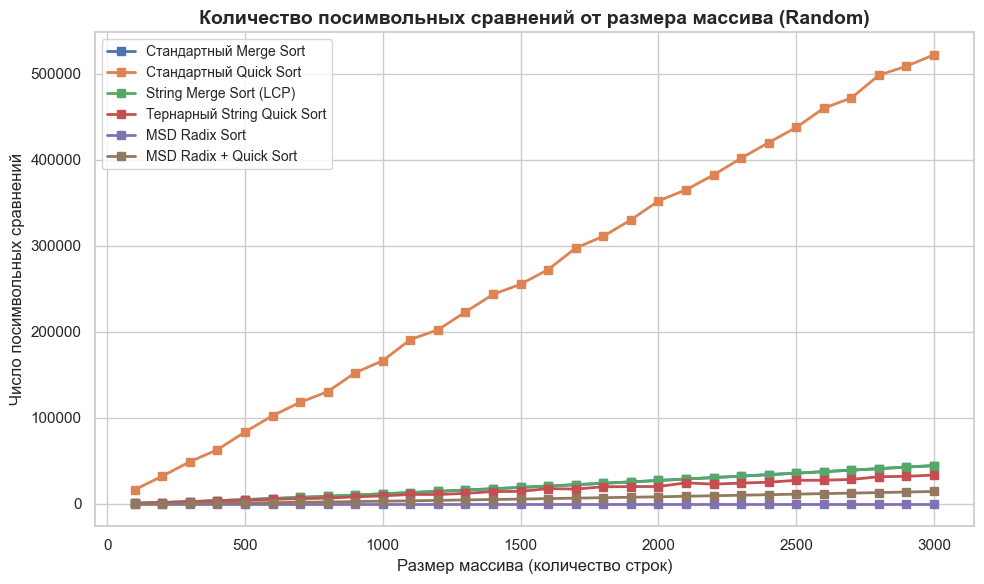

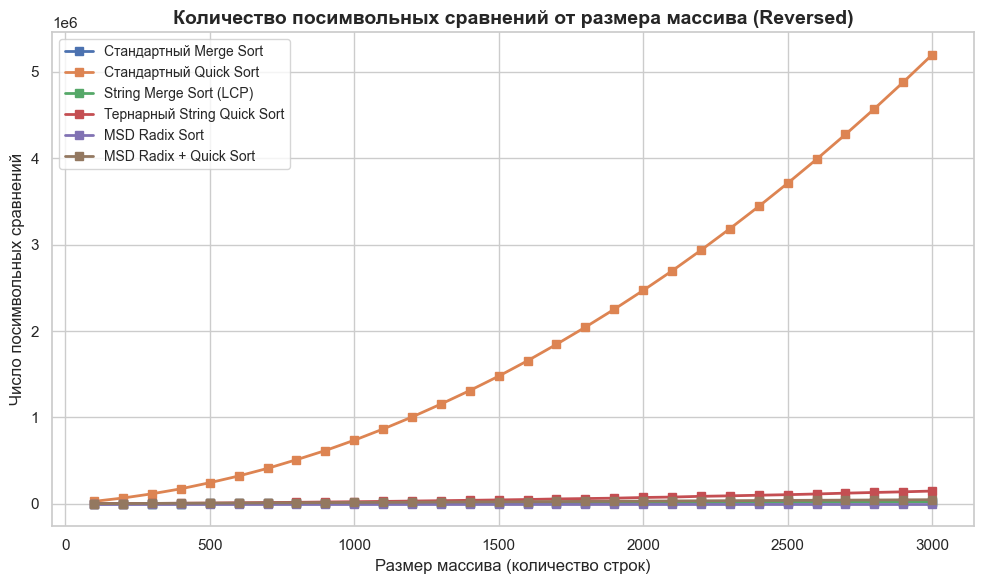

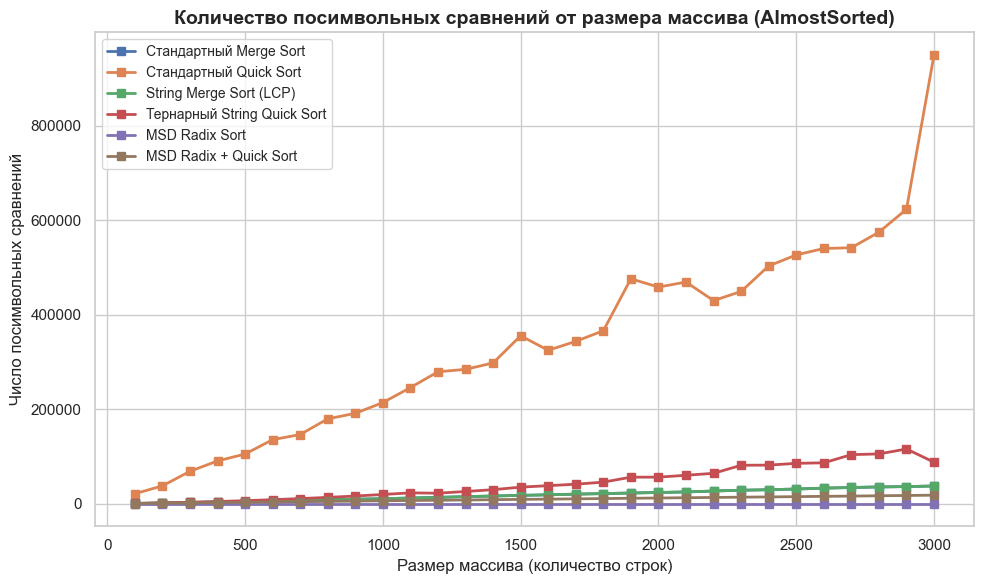

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv("report.csv", sep=";")

sns.set_theme(style="whitegrid")

# Получим список всех типов данных
data_types = df['DataType'].unique()

# Списки столбцов для графиков времени и сравнений
time_columns = ['StdMerge_ms', 'StdQuick_ms', 'StrMerge_ms', 'StrQuick_ms', 'MSD_ms', 'MSDHybrid_ms']
comp_columns = ['StdMerge_comps', 'StdQuick_comps', 'StrMerge_comps', 'StrQuick_comps', 'MSD_comps', 'MSDHybrid_comps']

# Русские названия для легенды
labels = {
    'StdMerge': 'Стандартный Merge Sort',
    'StdQuick': 'Стандартный Quick Sort',
    'StrMerge': 'String Merge Sort (LCP)',
    'StrQuick': 'Тернарный String Quick Sort',
    'MSD': 'MSD Radix Sort',
    'MSDHybrid': 'MSD Radix + Quick Sort'
}

# Цикл по всем типам данных для построения графиков ВРЕМЕНИ
for dt in data_types:
    # Фильтруем датафрейм по текущему типу данных
    df_filtered = df[df['DataType'] == dt]
    
    plt.figure(figsize=(10, 6))
    
    # Рисуем линию для каждого алгоритма
    for col in time_columns:
        alg_name = col.split('_')[0]
        plt.plot(df_filtered['Size'], df_filtered[col], marker='o', linewidth=2, label=labels[alg_name])
        
    plt.title(f'Зависимость времени работы от размера массива ({dt})', fontsize=14, fontweight='bold')
    plt.xlabel('Размер массива (количество строк)', fontsize=12)
    plt.ylabel('Время выполнения (мс)', fontsize=12)
    plt.legend(fontsize=10)
    plt.tight_layout()
    
    # Сохраняем график в картинку для отчета
    plt.savefig(f'time_{dt}.png', dpi=300)
    plt.show()

# Цикл по всем типам данных для построения графиков СРАВНЕНИЙ
for dt in data_types:
    df_filtered = df[df['DataType'] == dt]
    
    plt.figure(figsize=(10, 6))
    
    for col in comp_columns:
        alg_name = col.split('_')[0]
        plt.plot(df_filtered['Size'], df_filtered[col], marker='s', linewidth=2, label=labels[alg_name])
        
    plt.title(f'Количество посимвольных сравнений от размера массива ({dt})', fontsize=14, fontweight='bold')
    plt.xlabel('Размер массива (количество строк)', fontsize=12)
    plt.ylabel('Число посимвольных сравнений', fontsize=12)
    plt.legend(fontsize=10)
    plt.tight_layout()
    
    # Сохраняем график в картинку для отчета
    plt.savefig(f'comps_{dt}.png', dpi=300)
    plt.show()